<a href="https://colab.research.google.com/github/FusRaDa/biot670i_capstone_vaccination_project/blob/kalkidan-analysis-engine/perin_notebooks/California_State_Level_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## California State-Level Analysis
California was evaluated as a candidate for focused state-level analysis because of its relatively extensive
data availability.

The analysis uses population-normalized measles incidence (cases per 100,000)
and vaccination coverage. The same analytical framework used for the pooled
analysis is applied at the state level to maintain consistency.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import pearsonr, spearmanr

print("Analysis environment ready.")

Analysis environment ready.


In [3]:
base_url = "https://raw.githubusercontent.com/FusRaDa/biot670i_capstone_vaccination_project/main/app/data/"

cases = pd.read_csv(base_url + "tycho_cases.csv")
population = pd.read_csv(base_url + "population.csv")
coverage = pd.read_csv(base_url + "nis_vacc_coverage.csv")

print("Cases:", cases.shape)
print("Population:", population.shape)
print("Coverage:", coverage.shape)

Cases: (1151, 5)
Population: (1173, 3)
Coverage: (1545, 11)


In [4]:
panel_df = pd.merge(
    cases,
    population,
    on=["year", "state"],
    how="inner"
)

panel_df["measles_cases_per_100k"] = (
    panel_df["measles_cases"] /
    panel_df["population"] * 100000
)

measles_df = pd.merge(
    panel_df[
        [
            "year",
            "state",
            "measles_cases",
            "population",
            "measles_cases_per_100k"
        ]
    ],
    coverage[
        [
            "year",
            "state",
            "measles_coverage_pct"
        ]
    ],
    on=["year", "state"],
    how="inner"
)

measles_df = measles_df.dropna(
    subset=[
        "measles_coverage_pct",
        "measles_cases_per_100k"
    ]
)

print("Analysis dataset shape:", measles_df.shape)

display(measles_df.head())

Analysis dataset shape: (314, 6)


,year,state,measles_cases,population,measles_cases_per_100k,measles_coverage_pct
2,1995,AR,2.0,2535399.0,0.078883,90.43
3,1995,AZ,10.0,4432499.0,0.225606,82.29
4,1995,CA,108.0,31696582.0,0.340731,90.32
5,1995,CO,24.0,3826653.0,0.627180,88.62
6,1995,CT,2.0,3324144.0,0.060166,94.31


In [5]:
print(
    "Duplicate state-year rows:",
    measles_df.duplicated(["state", "year"]).sum()
)

print(
    "Year range:",
    measles_df["year"].min(),
    "-",
    measles_df["year"].max()
)

print(
    "Number of states:",
    measles_df["state"].nunique()
)

Duplicate state-year rows: 0
Year range: 1995 - 2017
Number of states: 49


In [7]:
california_df = (
    measles_df[
        measles_df["state"] == "CA"
    ]
    .sort_values("year")
    .copy()
)

print("CALIFORNIA DATA AVAILABILITY")
print("----------------------------")

print("Number of observations:", len(california_df))

print(
    "Year range:",
    california_df["year"].min(),
    "-",
    california_df["year"].max()
)

print(
    "Years with vaccination coverage:",
    california_df["measles_coverage_pct"].notna().sum()
)

print(
    "Years with normalized measles incidence:",
    california_df["measles_cases_per_100k"].notna().sum()
)

display(
    california_df[
        [
            "year",
            "measles_coverage_pct",
            "measles_cases_per_100k"
        ]
    ]
)

CALIFORNIA DATA AVAILABILITY
----------------------------
Number of observations: 10
Year range: 1995 - 2017
Years with vaccination coverage: 10
Years with normalized measles incidence: 10


,year,measles_coverage_pct,measles_cases_per_100k
4,1995,90.32,0.340731
52,1996,90.73,0.143665
101,1997,89.40,0.070800
150,1998,92.59,0.024251
199,1999,93.02,0.050747
248,2000,90.89,0.044133
297,2001,91.60,0.104410
345,2002,91.07,0.008603
1032,2016,90.93,0.061304
1082,2017,93.02,0.038131


I checked California as a potential state-level focus. After linking vaccination coverage with population-normalized measles incidence, California only has 10 overlapping observations in the current analytical dataset. The available years are 1995–2002 and 2016–2017, so there is also a large gap in the time series. Before we settle on California, I'm going to compare data availability across states to see if another state gives us a more complete series for the lag analysis.

In [8]:
state_summary = (
    measles_df
    .groupby("state")
    .agg(
        n_observations=("year", "count"),
        first_year=("year", "min"),
        last_year=("year", "max")
    )
    .sort_values("n_observations", ascending=False)
)

display(state_summary)

,n_observations,first_year,last_year
state,,,
CA,10,1995,2017
OH,10,1995,2017
HI,9,1995,2017
FL,9,1995,2017
AZ,9,1995,2017
IL,9,1995,2017
PA,9,1995,2017
MA,9,1995,2017
GA,9,1995,2017


In [9]:
state_continuity = []

for state, group in measles_df.groupby("state"):

    years = sorted(group["year"].unique())

    consecutive_pairs = sum(
        years[i + 1] - years[i] == 1
        for i in range(len(years) - 1)
    )

    state_continuity.append({
        "state": state,
        "total_observations": len(years),
        "consecutive_year_pairs": consecutive_pairs,
        "years_available": ", ".join(map(str, years))
    })

state_continuity_df = (
    pd.DataFrame(state_continuity)
    .sort_values(
        ["consecutive_year_pairs", "total_observations"],
        ascending=False
    )
)

display(state_continuity_df.head(15))

,state,total_observations,consecutive_year_pairs,years_available
4,CA,10,8,"1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002..."
33,OH,10,8,"1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002..."
3,AZ,9,7,"1995, 1996, 1997, 1998, 1999, 2000, 2001, 2016..."
13,IL,9,7,"1995, 1996, 1997, 1998, 1999, 2000, 2001, 2016..."
18,MA,9,7,"1995, 1996, 1997, 1998, 1999, 2000, 2001, 2016..."
36,PA,9,7,"1995, 1996, 1997, 1998, 1999, 2000, 2001, 2016..."
45,WA,9,7,"1995, 1996, 1997, 1998, 1999, 2000, 2001, 2016..."
8,FL,9,6,"1995, 1996, 1997, 1998, 1999, 2000, 2002, 2016..."
9,GA,9,6,"1995, 1996, 1997, 1998, 1999, 2001, 2002, 2016..."
10,HI,9,6,"1995, 1996, 1997, 1999, 2000, 2001, 2002, 2016..."


California: 10 observations, 8 consecutive-year pairs

## California 0–5 Year Lag Analysis

California was selected for focused analysis because it had one of the
highest levels of longitudinal data availability in the linked analytical
dataset.

The following analysis compares measles vaccination coverage in year t with
population-normalized measles incidence occurring 0 to 5 calendar years later.

Exact calendar-year matching is used so that gaps in the available data are
not incorrectly treated as consecutive observations.

In [10]:
ca_lag_results = []

for lag in range(0, 6):

    coverage_ca = california_df[
        ["year", "measles_coverage_pct"]
    ].copy()

    incidence_ca = california_df[
        ["year", "measles_cases_per_100k"]
    ].copy()

    # Match coverage at year t with incidence at year t + lag
    incidence_ca["year"] = incidence_ca["year"] - lag

    temp = coverage_ca.merge(
        incidence_ca,
        on="year",
        how="inner"
    ).dropna()

    if len(temp) >= 3:
        r, p = pearsonr(
            temp["measles_coverage_pct"],
            temp["measles_cases_per_100k"]
        )
    else:
        r, p = np.nan, np.nan

    ca_lag_results.append({
        "lag_years": lag,
        "pearson_r": r,
        "p_value": p,
        "n": len(temp)
    })

ca_lag_results_df = pd.DataFrame(ca_lag_results)

display(ca_lag_results_df)

,lag_years,pearson_r,p_value,n
0,0,-0.410431,0.238750,10
1,1,-0.229362,0.584790,8
2,2,0.408643,0.421155,6
3,3,0.148758,0.811297,5
4,4,-0.942227,0.057773,4
5,5,0.933798,0.232946,3



California had 10 matched observations for the same-year analysis, with the
number of available observations decreasing as the lag period increased.

The same-year analysis showed a moderate negative association between measles
vaccination coverage and population-normalized measles incidence
(r = -0.410, p = 0.239, n = 10). The 1-year lag showed a weaker negative
association (r = -0.229, p = 0.585, n = 8).

Correlation estimates became unstable at longer lag periods as the available
sample decreased from 6 observations at the 2-year lag to only 3 observations
at the 5-year lag. For example, the 4-year and 5-year correlations were large
in magnitude but were based on only 4 and 3 observations, respectively.

Therefore, the longer-lag California estimates should be treated as
exploratory and should not be interpreted as evidence of a strong association
or causation. The pooled state-year analysis provides substantially more
statistical information, while California may be more appropriate as a
focused descriptive case study.

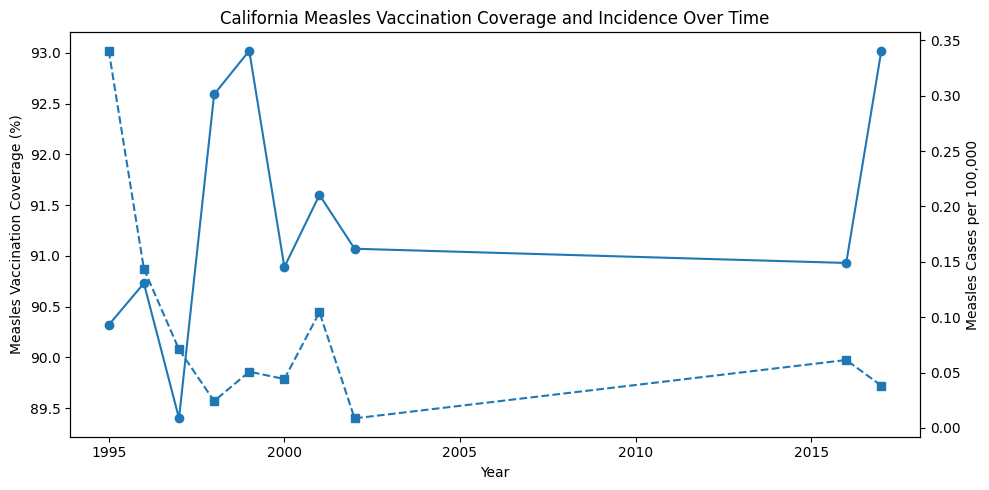

In [12]:
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(10, 5))

# Vaccination coverage
ax1.plot(
    california_df["year"],
    california_df["measles_coverage_pct"],
    marker="o"
)

ax1.set_xlabel("Year")
ax1.set_ylabel("Measles Vaccination Coverage (%)")

# Measles incidence on second axis
ax2 = ax1.twinx()

ax2.plot(
    california_df["year"],
    california_df["measles_cases_per_100k"],
    marker="s",
    linestyle="--"
)

ax2.set_ylabel("Measles Cases per 100,000")

plt.title(
    "California Measles Vaccination Coverage and Incidence Over Time"
)

fig.tight_layout()
plt.show()

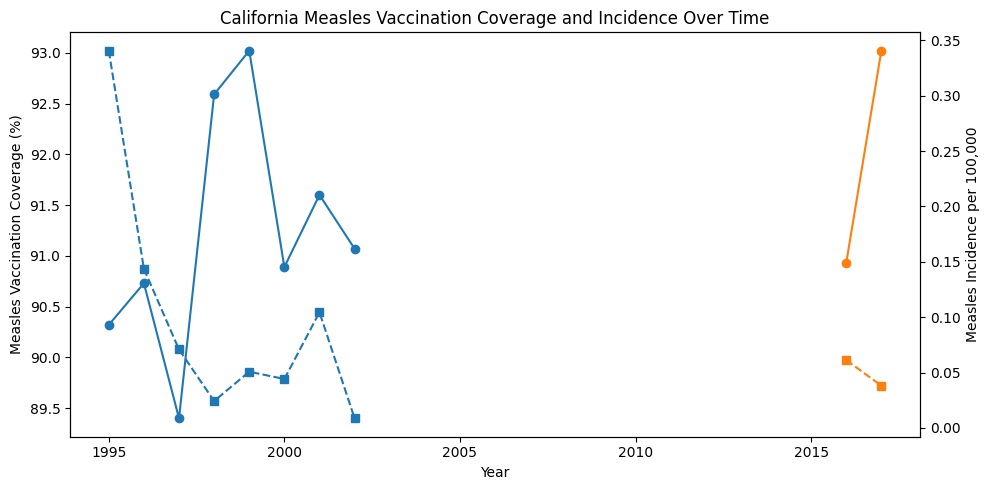

In [13]:
import matplotlib.pyplot as plt
import numpy as np

plot_df = california_df[
    ["year", "measles_coverage_pct", "measles_cases_per_100k"]
].copy().sort_values("year")

# Identify gaps larger than one calendar year
plot_df["year_gap"] = plot_df["year"].diff()

fig, ax1 = plt.subplots(figsize=(10, 5))

# Plot each continuous segment separately
segment = (plot_df["year_gap"] > 1).cumsum()

for _, group in plot_df.groupby(segment):

    ax1.plot(
        group["year"],
        group["measles_coverage_pct"],
        marker="o"
    )

ax1.set_xlabel("Year")
ax1.set_ylabel("Measles Vaccination Coverage (%)")

ax2 = ax1.twinx()

for _, group in plot_df.groupby(segment):

    ax2.plot(
        group["year"],
        group["measles_cases_per_100k"],
        marker="s",
        linestyle="--"
    )

ax2.set_ylabel("Measles Incidence per 100,000")

plt.title(
    "California Measles Vaccination Coverage and Incidence Over Time"
)

fig.tight_layout()
plt.show()

In [14]:
from scipy.stats import pearsonr, spearmanr

# Keep only complete California observations
ca_baseline = california_df[
    ["measles_coverage_pct", "measles_cases_per_100k"]
].dropna()

# Pearson correlation
ca_r, ca_p = pearsonr(
    ca_baseline["measles_coverage_pct"],
    ca_baseline["measles_cases_per_100k"]
)

# Spearman correlation
ca_rho, ca_spearman_p = spearmanr(
    ca_baseline["measles_coverage_pct"],
    ca_baseline["measles_cases_per_100k"]
)

print("CALIFORNIA MEASLES BASELINE ANALYSIS")
print("------------------------------------")
print(f"Pearson r:     {ca_r:.3f}")
print(f"Pearson p:     {ca_p:.4f}")
print(f"Spearman rho:  {ca_rho:.3f}")
print(f"Spearman p:    {ca_spearman_p:.4f}")
print(f"n:             {len(ca_baseline)}")

CALIFORNIA MEASLES BASELINE ANALYSIS
------------------------------------
Pearson r:     -0.410
Pearson p:     0.2388
Spearman rho:  -0.590
Spearman p:    0.0728
n:             10



Among the 10 available California state-year observations, measles vaccination
coverage showed a negative association with population-normalized measles
incidence.

- **Pearson correlation:** r = -0.410, p = 0.2388
- **Spearman correlation:** ρ = -0.590, p = 0.0728
- **n = 10**

Both correlation measures indicate a negative relationship, although neither
was statistically significant at the conventional 0.05 level.

The Spearman correlation was stronger than the Pearson correlation, it shows
that the relationship may be more consistently monotonic than strictly linear.
However, the small sample size and gaps in available years substantially limit
statistical precision.

These results represent an ecological association and should not be interpreted
as evidence of causation.

In [15]:
# Create canonical California analysis dataset for dashboard use

california_analysis_table = (
    california_df[
        [
            "year",
            "state",
            "measles_coverage_pct",
            "measles_cases_per_100k"
        ]
    ]
    .dropna()
    .sort_values("year")
    .reset_index(drop=True)
)

display(california_analysis_table)

,year,state,measles_coverage_pct,measles_cases_per_100k
0,1995,CA,90.32,0.340731
1,1996,CA,90.73,0.143665
2,1997,CA,89.40,0.070800
3,1998,CA,92.59,0.024251
4,1999,CA,93.02,0.050747
5,2000,CA,90.89,0.044133
6,2001,CA,91.60,0.104410
7,2002,CA,91.07,0.008603
8,2016,CA,90.93,0.061304
9,2017,CA,93.02,0.038131


In [17]:
# Add analysis-ready fields

california_analysis_table["coverage_change"] = (
    california_analysis_table["measles_coverage_pct"].diff()
)

california_analysis_table["incidence_change"] = (
    california_analysis_table["measles_cases_per_100k"].diff()
)

# Flag whether the current row follows the previous calendar year
california_analysis_table["consecutive_year"] = (
    california_analysis_table["year"].diff() == 1
)

display(california_analysis_table)


# Keep change values only for consecutive calendar years
california_analysis_table.loc[
    ~california_analysis_table["consecutive_year"],
    ["coverage_change", "incidence_change"]
] = np.nan

display(california_analysis_table)

,year,state,measles_coverage_pct,measles_cases_per_100k,coverage_change,incidence_change,consecutive_year
0,1995,CA,90.32,0.340731,NaN,NaN,False
1,1996,CA,90.73,0.143665,0.41,-0.197065,True
2,1997,CA,89.40,0.070800,-1.33,-0.072866,True
3,1998,CA,92.59,0.024251,3.19,-0.046548,True
4,1999,CA,93.02,0.050747,0.43,0.026496,True
5,2000,CA,90.89,0.044133,-2.13,-0.006614,True
6,2001,CA,91.60,0.104410,0.71,0.060277,True
7,2002,CA,91.07,0.008603,-0.53,-0.095807,True
8,2016,CA,90.93,0.061304,-0.14,0.052701,False
9,2017,CA,93.02,0.038131,2.09,-0.023173,True


,year,state,measles_coverage_pct,measles_cases_per_100k,coverage_change,incidence_change,consecutive_year
0,1995,CA,90.32,0.340731,NaN,NaN,False
1,1996,CA,90.73,0.143665,0.41,-0.197065,True
2,1997,CA,89.40,0.070800,-1.33,-0.072866,True
3,1998,CA,92.59,0.024251,3.19,-0.046548,True
4,1999,CA,93.02,0.050747,0.43,0.026496,True
5,2000,CA,90.89,0.044133,-2.13,-0.006614,True
6,2001,CA,91.60,0.104410,0.71,0.060277,True
7,2002,CA,91.07,0.008603,-0.53,-0.095807,True
8,2016,CA,90.93,0.061304,NaN,NaN,False
9,2017,CA,93.02,0.038131,2.09,-0.023173,True


In [18]:
california_analysis_table.to_csv(
    "california_measles_analysis.csv",
    index=False
)

print("Canonical California analytical dataset saved.")

Canonical California analytical dataset saved.


In [19]:
california_results_table = ca_lag_results_df.copy()

california_results_table["state"] = "CA"
california_results_table["disease"] = "measles"
california_results_table["outcome"] = "incidence_per_100k"

california_results_table = california_results_table[
    [
        "state",
        "disease",
        "outcome",
        "lag_years",
        "pearson_r",
        "p_value",
        "n"
    ]
]

display(california_results_table)

,state,disease,outcome,lag_years,pearson_r,p_value,n
0,CA,measles,incidence_per_100k,0,-0.410431,0.238750,10
1,CA,measles,incidence_per_100k,1,-0.229362,0.584790,8
2,CA,measles,incidence_per_100k,2,0.408643,0.421155,6
3,CA,measles,incidence_per_100k,3,0.148758,0.811297,5
4,CA,measles,incidence_per_100k,4,-0.942227,0.057773,4
5,CA,measles,incidence_per_100k,5,0.933798,0.232946,3


In [20]:
california_results_table.to_csv(
    "california_measles_lag_results.csv",
    index=False
)

print("Canonical California analysis-results table saved.")

Canonical California analysis-results table saved.
